In [193]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# data visualisation and manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

import tensorflow
 
#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

#preprocess.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#dl libraraies
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical
from keras.preprocessing import image

# specifically for cnn
from keras.layers import Dropout, Flatten,Activation,Lambda
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
 
import tensorflow as tf
import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
import cv2                  
import numpy as np  
from tqdm import tqdm
import os                   
from random import shuffle  
from zipfile import ZipFile
from PIL import Image

In [194]:
X=[]
Z=[]
IMG_SIZE=150

covid_dir='/kaggle/input/convolutional-neural-network-cnn-practice/COVID_IEEE/train/covid'
normal_dir='/kaggle/input/convolutional-neural-network-cnn-practice/COVID_IEEE/train/normal'
virus_dir='/kaggle/input/convolutional-neural-network-cnn-practice/COVID_IEEE/train/virus'

def assign_label(img,xray_type):
    return xray_type

def make_train_data(xray_type,DIR):
    for img in tqdm(os.listdir(DIR)):
        label=assign_label(img,xray_type)
        path = os.path.join(DIR,img)
        img = cv2.imread(path,cv2.IMREAD_GRAYSCALE) 
        #now it is an array
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        
        X.append(np.array(img))
        Z.append(str(label))
        


In [195]:
make_train_data('covid',covid_dir)
print(len(X))

100%|██████████| 428/428 [00:00<00:00, 534.63it/s]

428


In [196]:
make_train_data('normal',normal_dir)
make_train_data('virus',virus_dir)
print(len(X))

100%|██████████| 495/495 [00:00<00:00, 553.75it/s]

1458


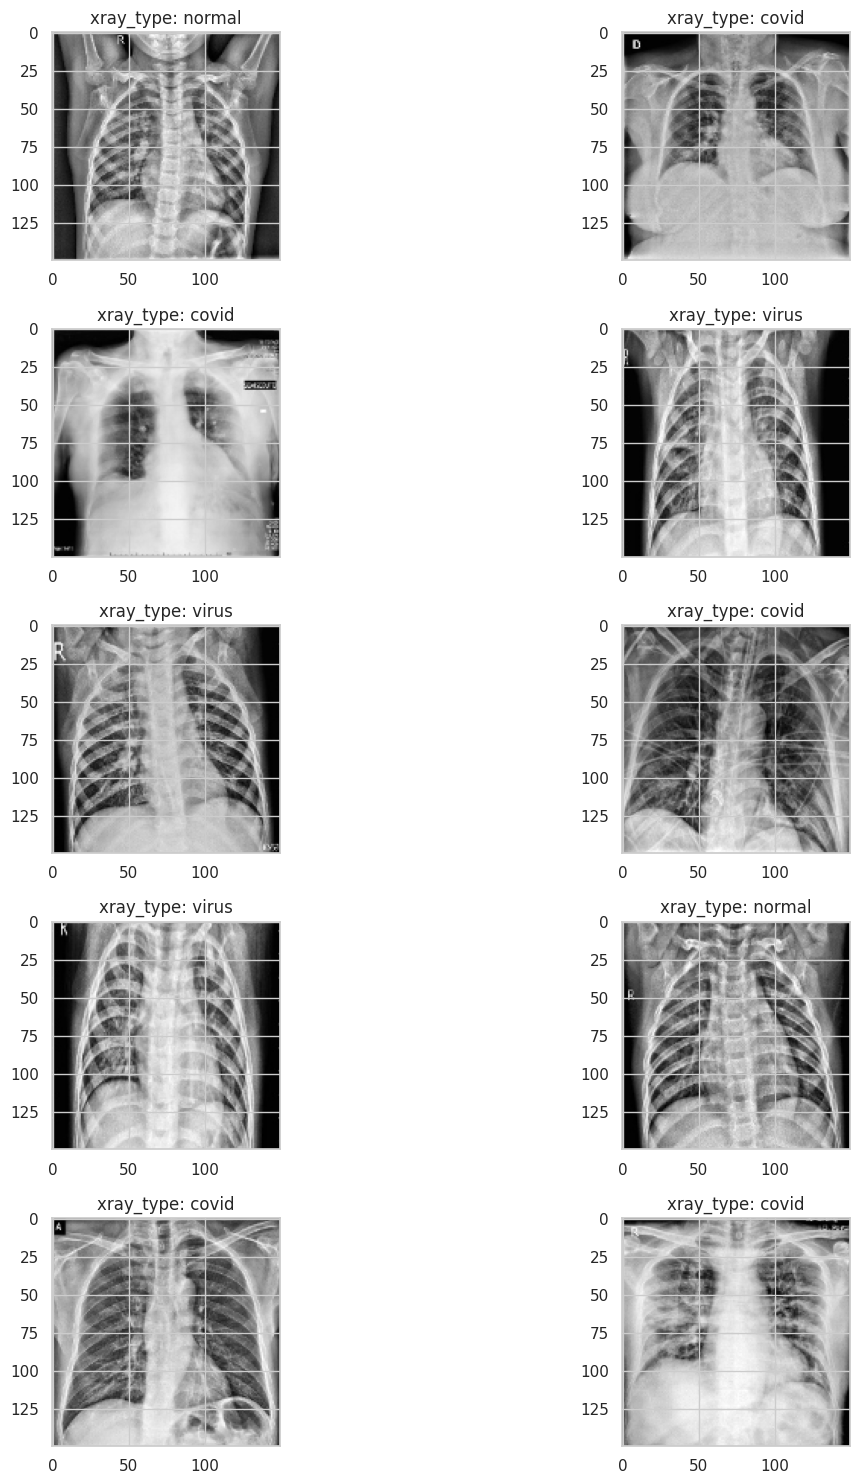

In [197]:
fig,ax=plt.subplots(5,2)
fig.set_size_inches(15,15)
for i in range(5):
    for j in range (2):
        l=rn.randint(0,len(Z))
        ax[i,j].imshow(X[l],cmap=plt.get_cmap("gray"))
        ax[i,j].set_title('xray_type: '+Z[l])
        
plt.tight_layout()
# X[:3]

In [198]:
le=LabelEncoder()
Y=le.fit_transform(Z)

Y=to_categorical(Y,3)
X=np.array(X)
X = X.reshape((1458, 150, 150, 1))

In [199]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [200]:
#not splitting before the model

#random seed 
np.random.seed(42)
rn.seed(42)
tf.random.set_seed(42)
batch_size=32
epochs=15

In [201]:
#building the model

model = Sequential()
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'same',activation ='relu', input_shape = (150,150,1)))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
 

model.add(Conv2D(filters =96, kernel_size = (3,3),padding = 'same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters = 96, kernel_size = (3,3),padding = 'same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dense(3, activation = "softmax"))

In [202]:
#LR
from keras.callbacks import ReduceLROnPlateau
red_lr= ReduceLROnPlateau(monitor='val_acc',patience=3,verbose=1,factor=0.1)

In [203]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=True)  # randomly flip images

#make vertical flip true 


datagen.fit(x_train)

In [204]:
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [205]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)                   │ (None, 150, 150, 32)        │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_62 (Conv2D)                   │ (None, 37, 37, 96)          │          55,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_62 (MaxPooling2D)      │ (None, 18, 18, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_63 (Conv2D)                   │ (None, 18, 18, 96)          │          83,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_63 (MaxPooling2D)      │ (None, 9, 9, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 7776)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 512)                 │       3,981,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_15 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,141,123 (15.80 MB)

 Trainable params: 4,141,123 (15.80 MB)

 Non-trainable params: 0 (0.00 B)

In [206]:
History = model.fit(datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (x_test,y_test),
                              verbose = 1, steps_per_epoch=x_train.shape[0] // batch_size)

Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.4342 - loss: 13.5640 - val_accuracy: 0.5507 - val_loss: 0.8643
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.5938 - loss: 0.9834 - val_accuracy: 0.5753 - val_loss: 0.7792
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6343 - loss: 0.7287 - val_accuracy: 0.7753 - val_loss: 0.5933
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.9062 - loss: 0.3911 - val_accuracy: 0.7863 - val_loss: 0.5689
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.7647 - loss: 0.5930 - val_accuracy: 0.7836 - val_loss: 0.5959
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.9062 - loss: 0.3266 - val_accuracy: 0.7973 - val_loss: 0.5607
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8340 - loss: 0.4434 - val_accuracy: 0.7918 - val_loss: 0.6026
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8125 - loss: 0.4369 - val_accuracy: 0.7808 - val_

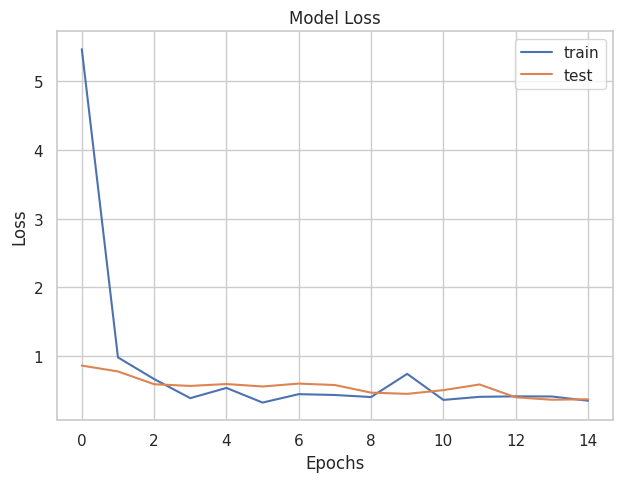

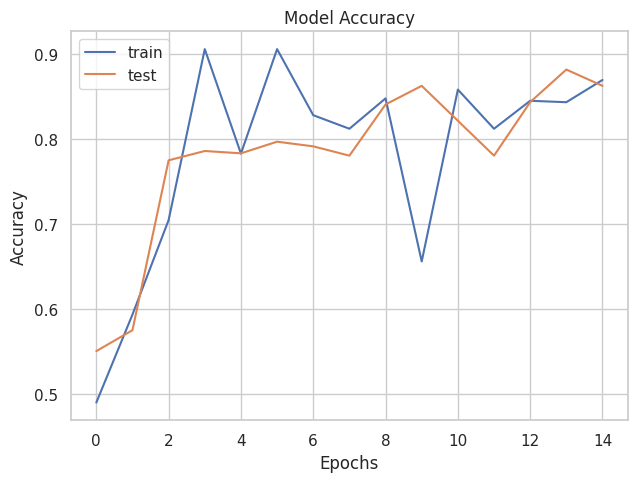

In [207]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

In [209]:
test_dir='/kaggle/input/convolutional-neural-network-cnn-practice/COVID_IEEE/test'

test=[]
# def assign_label(img,xray_type):
#     return xray_type

def make_test_data(DIR):
    for img in tqdm(os.listdir(DIR)):
        path = os.path.join(DIR,img)
        img = cv2.imread(path,cv2.IMREAD_GRAYSCALE) 
        #now it is an array
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        
        test.append(np.array(img))
        

In [210]:
make_test_data(test_dir)

100%|██████████| 366/366 [00:03<00:00, 98.63it/s] 


In [215]:
test=np.array(test)
test=test.reshape(366,150,150,1)

In [226]:
predictions = model.predict(test, verbose=1)
print(predictions[:3])
predictions=pd.DataFrame(predictions,columns=["covid","normal","virus"])

predictions['MaxTitle'] = predictions.iloc[:, :].idxmax(axis=1)
print(predictions[:3])

submissions=pd.DataFrame({"Id": list(range(1,len(predictions)+1)),
                          "Label": predictions["MaxTitle"]})
submissions.to_csv("covid.csv", index=False, header=True)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step
[[0.00559222 0.18535393 0.8090538 ]
 [0.73811984 0.042077   0.2198032 ]
 [0.46400228 0.05057158 0.48542613]]
      covid    normal     virus MaxTitle
0  0.005592  0.185354  0.809054    virus
1  0.738120  0.042077  0.219803    covid
2  0.464002  0.050572  0.485426    virus
